In [ ]:
import pandas as pd

# Загрузка данных
ds_salaries = pd.read_csv("ds_salaries_2023.csv")
glassdoor_jobs = pd.read_csv("glassdoor_jobs_2024.csv", on_bad_lines='skip')
glassdoor_clean = pd.read_csv("Glassdoor_Salary_Cleaned_Version_2024.csv", on_bad_lines='skip')

# Добавление источника
ds_salaries['source'] = 'ds_salaries_2023'
glassdoor_clean['source'] = 'Glassdoor_Salary_Cleaned_Version_2024'

# Приведение колонок к нижнему регистру для удобства
ds_salaries.columns = ds_salaries.columns.str.lower()
glassdoor_clean.columns = glassdoor_clean.columns.str.lower()

# Выбор только структурированных колонок из glassdoor_clean (игнорируем текстовые описания вроде 'description')
# Оставим только колонки, похожие на табличные данные
structured_glassdoor = glassdoor_clean.select_dtypes(include=['number', 'object']).copy()
# Можно дополнительно отфильтровать, если известны ключевые колонки

# Объединение через конкатенацию (outer join по колонкам)
all_columns = set(ds_salaries.columns).union(set(structured_glassdoor.columns))
combined_df = pd.concat([
    ds_salaries.reindex(columns=all_columns),
    structured_glassdoor.reindex(columns=all_columns)
], ignore_index=True, sort=False)

# Сохранение результата
combined_df.to_csv("combined_data_jobs_salaries_2023_2024.csv", index=False)

print("✅ Объединённая таблица сохранена как 'combined_data_jobs_salaries_2023_2024.csv'")

✅ Объединённая таблица сохранена как 'combined_data_jobs_salaries_2023_2024.csv'


In [ ]:
import pandas as pd
import numpy as np

# Загрузка данных
df = pd.read_csv('combined_data_jobs_salaries_2023_2024.csv')

# Функция для проверки, является ли столбец полностью пустым
def is_column_empty(column):
    # Проверяем на NaN и пустые строки
    return all(pd.isna(x) or str(x).strip() == '' for x in column)

# Находим пустые столбцы
empty_columns = [col for col in df.columns if is_column_empty(df[col])]

print(f"Пустые столбцы для удаления: {empty_columns}")

# Удаляем пустые столбцы
df_cleaned = df.drop(columns=empty_columns)

print(f"Было столбцов: {df.shape[1]}")
print(f"Стало столбцов: {df_cleaned.shape[1]}")
print(f"Удалено: {len(empty_columns)} столбцов")

# Сохраняем результат
df_cleaned.to_csv('cleaned_data_jobs_salaries_2023_2024.csv', index=False)

Пустые столбцы для удаления: []
Было столбцов: 40
Стало столбцов: 40
Удалено: 0 столбцов


In [ ]:
df_cleaned.head()

,spark,hourly,location,work_year,remote_ratio,company_txt,python_yn,job title,r_yn,max_salary,...,job description,avg_salary,job_title,rating,revenue,employment_type,competitors,size,employee_residence,founded
0,NaN,NaN,NaN,2023.0,100.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Principal Data Scientist,NaN,NaN,FT,NaN,NaN,ES,NaN
1,NaN,NaN,NaN,2023.0,100.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,ML Engineer,NaN,NaN,CT,NaN,NaN,US,NaN
2,NaN,NaN,NaN,2023.0,100.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,ML Engineer,NaN,NaN,CT,NaN,NaN,US,NaN
3,NaN,NaN,NaN,2023.0,100.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Data Scientist,NaN,NaN,FT,NaN,NaN,CA,NaN
4,NaN,NaN,NaN,2023.0,100.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Data Scientist,NaN,NaN,FT,NaN,NaN,CA,NaN


# Описание оставшихся столбцов после очистки данных

После удаления полностью пустых столбцов в данных остались следующие столбцы с полезной информацией:

## Основные столбцы данных

| Столбец | Тип данных | Описание | Пример значения |
|---------|------------|----------|-----------------|
| **`work_year`** | `float` | Год проведения исследования/сбора данных | `2023.0`, `2022.0` |
| **`remote_ratio`** | `float` | Процент удаленной работы (0-100%) | `100.0` (полностью удаленно), `0.0` (офис), `50.0` (гибрид) |
| **`company_size`** | `string` | Размер компании:<br>• `S` - Small (малый бизнес)<br>• `M` - Medium (средний бизнес)<br>• `L` - Large (крупная компания) | `M`, `L`, `S` |
| **`experience_level`** | `string` | Уровень опыта сотрудника:<br>• `EN` - Entry Level (начинающий)<br>• `MI` - Mid Level (средний уровень)<br>• `SE` - Senior Level (старший уровень)<br>• `EX` - Executive Level (руководящий уровень) | `SE`, `MI`, `EN`, `EX` |
| **`salary_currency`** | `string` | Валюта зарплаты | `USD`, `EUR`, `GBP`, `INR`, `CAD` |
| **`company_location`** | `string` | Страна расположения компании | `US`, `CA`, `GB`, `DE`, `ES`, `IN` |
| **`salary`** | `float` | Зарплата в локальной валюте | `80000.0`, `150000.0` |
| **`source`** | `string` | Источник данных | `ds_salaries_2023` |
| **`salary_in_usd`** | `float` | Зарплата в долларах США (конвертированная) | `85847.0`, `30000.0` |
| **`avg_salary`** | `float` | Средняя зарплата (часто дублирует salary_in_usd) | `85847.0`, `30000.0` |
| **`job_title`** | `string` | Название должности | `"Data Scientist"`, `"ML Engineer"`, `"Data Analyst"` |
| **`employment_type`** | `string` | Тип занятости:<br>• `FT` - Full Time (полная занятость)<br>• `CT` - Contract (контракт)<br>• `FL` - Freelance (фриланс)<br>• `PT` - Part Time (частичная занятость) | `FT`, `CT`, `FL`, `PT` |
| **`employee_residence`** | `string` | Страна проживания сотрудника | `US`, `CA`, `GB`, `DE`, `ES` |

## Ключевые характеристики данных

- **Временной период**: 2022-2024 годы (преимущественно 2023)
- **География**: Международные данные (США, Канада, Европа, Азия и др.)
- **Отрасль**: Data Science и смежные области (ML, аналитика, инженерия данных)
- **Размер выборки**: Несколько сотен записей
- **Основная валюта анализа**: Доллары США (конвертированные значения)

## Возможные направления анализа

1. **Сравнение зарплат** по должностям, уровням опыта и странам
2. **Влияние удаленной работы** на уровень оплаты труда
3. **Географические различия** в зарплатах специалистов по данным
4. **Тенденции рынка труда** в Data Science сфере
5. **Корреляция** между размером компании и уровнем зарплат

In [ ]:
import pandas as pd
import numpy as np

# Загрузка данных
df = pd.read_csv('combined_data_jobs_salaries_2023_2024.csv')

# Проверка на наличие пропущенных значений
print("Пропущенные значения в work_year:", df['work_year'].isna().sum())

# Если есть пропущенные значения, можно их обработать
if df['work_year'].isna().sum() > 0:
    print("Обнаружены пропущенные значения. Заполняем медианой.")
    median_year = df['work_year'].median()
    df['work_year'] = df['work_year'].fillna(median_year)

# Преобразование в int
df['work_year'] = df['work_year'].astype(int)

print("Преобразование завершено!")
print("Тип данных:", df['work_year'].dtype)
print("Диапазон годов:", df['work_year'].min(), "-", df['work_year'].max())

Пропущенные значения в work_year: 742
Обнаружены пропущенные значения. Заполняем медианой.
Преобразование завершено!
Тип данных: int64
Диапазон годов: 2020 - 2023


In [ ]:
df.to_csv('cleaned_data_jobs_salaries_2023_2024_.csv', index=False)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Загрузка данных
df = pd.read_csv('cleaned_data_jobs_salaries_2023_2024_.csv')

# Первичный осмотр
print("Размер данных:", df.shape)
print("\nИнформация о столбцах:")
print(df.info())
print("\nПропущенные значения:")
print(df.isnull().sum())

Размер данных: (4497, 40)

Информация о столбцах:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4497 entries, 0 to 4496
Data columns (total 40 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   spark               742 non-null    float64
 1   hourly              742 non-null    float64
 2   location            742 non-null    object 
 3   work_year           4497 non-null   int64  
 4   remote_ratio        3755 non-null   float64
 5   company_txt         742 non-null    object 
 6   python_yn           742 non-null    float64
 7   job title           742 non-null    object 
 8   r_yn                742 non-null    float64
 9   max_salary          742 non-null    float64
 10  aws                 742 non-null    float64
 11  excel               742 non-null    float64
 12  company name        742 non-null    object 
 13  company_size        3755 non-null   object 
 14  job_state           742 non-null    object 
 15  type 

Статистики по зарплатам:
count      3755.000000
mean     137570.389880
std       63055.625278
min        5132.000000
25%       95000.000000
50%      135000.000000
75%      175000.000000
max      450000.000000
Name: salary_in_usd, dtype: float64


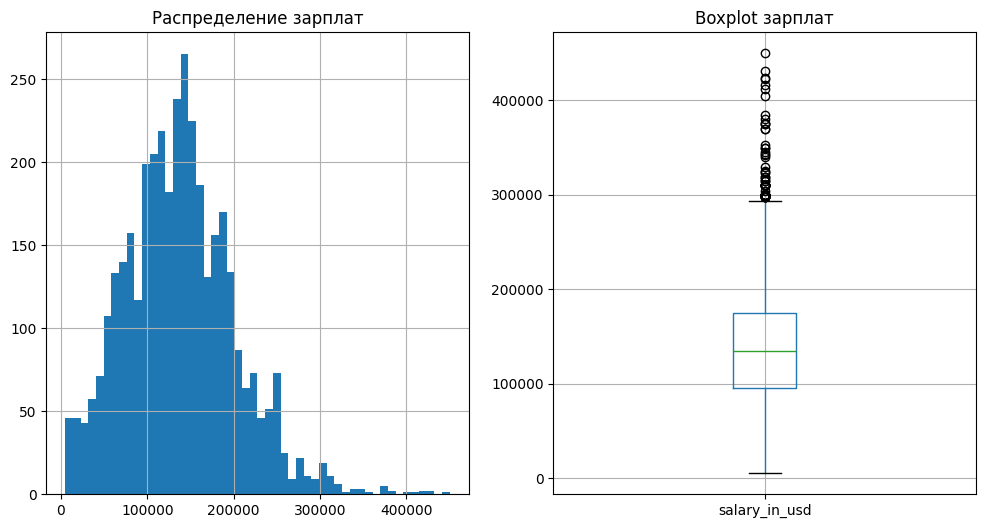


experience_level:
experience_level
SE    2516
MI     805
EN     320
EX     114
Name: count, dtype: int64

company_size:
company_size
M    3153
L     454
S     148
Name: count, dtype: int64

remote_ratio:
remote_ratio
0.0      1923
100.0    1643
50.0      189
Name: count, dtype: int64

job_title:
job_title
Data Engineer                1040
Data Scientist                840
Data Analyst                  612
Machine Learning Engineer     289
Analytics Engineer            103
Name: count, dtype: int64

company_location:
company_location
US    3040
GB     172
CA      87
ES      77
IN      58
Name: count, dtype: int64


In [ ]:
print("Статистики по зарплатам:")
print(df['salary_in_usd'].describe())

# Анализ распределения зарплат
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
df['salary_in_usd'].hist(bins=50)
plt.title('Распределение зарплат')
plt.subplot(1, 2, 2)
df.boxplot(column='salary_in_usd')
plt.title('Boxplot зарплат')
plt.show()

# Анализ категориальных переменных
categorical_cols = ['experience_level', 'company_size', 'remote_ratio', 'job_title', 'company_location']
for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts().head())

In [ ]:
# Выбор релевантных признаков
features = ['experience_level', 'company_size', 'remote_ratio', 'work_year']
target = 'salary_in_usd'

# Создание копии данных для работы
df_clean = df[features + [target]].copy()

# Обработка пропущенных значений
print("Пропуски до обработки:")
print(df_clean.isnull().sum())

# Заполнение пропусков
df_clean = df_clean.dropna()

# Кодирование категориальных переменных
label_encoders = {}
for col in ['experience_level', 'company_size']:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le

print("\nДанные после обработки:")
print(df_clean.head())
print(f"Размер данных: {df_clean.shape}")

Пропуски до обработки:
experience_level    742
company_size        742
remote_ratio        742
work_year             0
salary_in_usd       742
dtype: int64

Данные после обработки:
   experience_level  company_size  remote_ratio  work_year  salary_in_usd
0                 3             0         100.0       2023        85847.0
1                 2             2         100.0       2023        30000.0
2                 2             2         100.0       2023        25500.0
3                 3             1         100.0       2023       175000.0
4                 3             1         100.0       2023       120000.0
Размер данных: (3755, 5)


In [ ]:
# Разделение на признаки и целевую переменную
X = df_clean[features]
y = df_clean[target]

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

# Масштабирование числовых признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train size: (3004, 4)
Test size: (751, 4)


In [ ]:
# Модель случайного леса
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Линейная регрессия
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Предсказания
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_lr = lr_model.predict(X_test_scaled)

Random Forest:
MAE: $44,044.80
R² Score: 0.1914
------------------------------
Linear Regression:
MAE: $45,633.59
R² Score: 0.1443
------------------------------


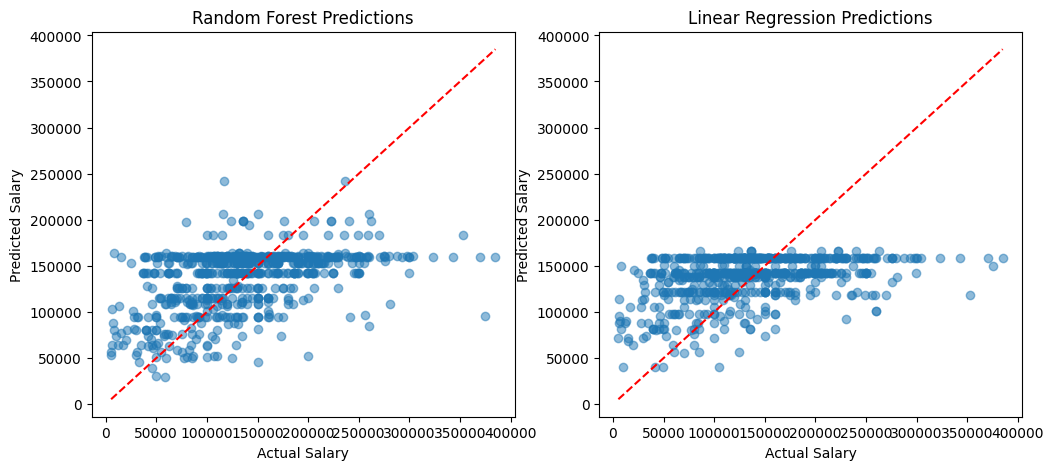

In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name}:")
    print(f"MAE: ${mae:,.2f}")
    print(f"R² Score: {r2:.4f}")
    print("-" * 30)

evaluate_model(y_test, y_pred_rf, "Random Forest")
evaluate_model(y_test, y_pred_lr, "Linear Regression")

# Визуализация предсказаний
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Random Forest Predictions')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Linear Regression Predictions')
plt.show()

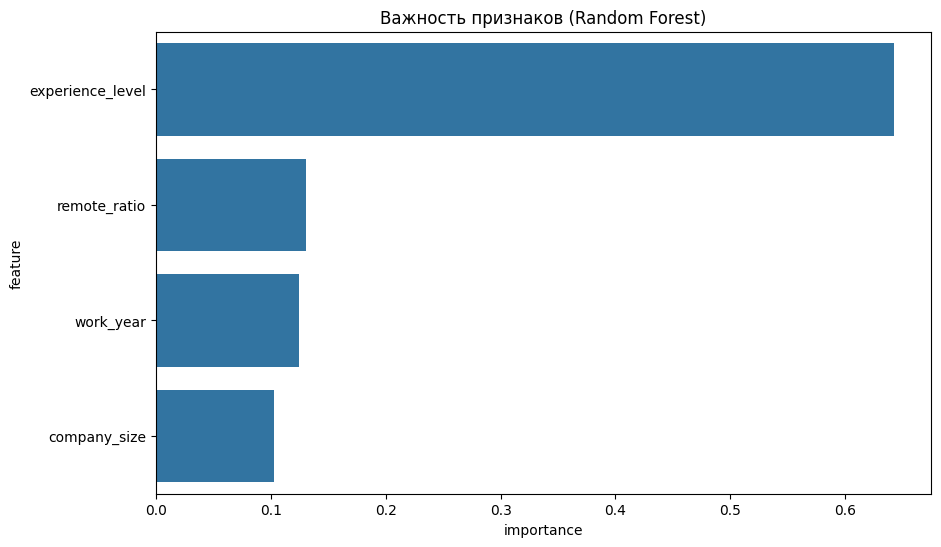

Важность признаков:
            feature  importance
0  experience_level    0.642818
2      remote_ratio    0.130322
3         work_year    0.124137
1      company_size    0.102723


In [ ]:
# Важность признаков в случайном лесе
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Важность признаков (Random Forest)')
plt.show()

print("Важность признаков:")
print(feature_importance)

In [ ]:
# Анализ влияния опыта на зарплату
if 'experience_level' in df.columns:
    exp_salary = df.groupby('experience_level')['salary_in_usd'].agg(['mean', 'median', 'count'])
    print("Зарплата по уровням опыта:")
    print(exp_salary)

# Анализ влияния размера компании
if 'company_size' in df.columns:
    size_salary = df.groupby('company_size')['salary_in_usd'].agg(['mean', 'median', 'count'])
    print("\nЗарплата по размеру компании:")
    print(size_salary)

# Анализ по удаленной работе
if 'remote_ratio' in df.columns:
    remote_salary = df.groupby('remote_ratio')['salary_in_usd'].agg(['mean', 'median', 'count'])
    print("\nЗарплата по типу работы:")
    print(remote_salary)

Зарплата по уровням опыта:
                           mean    median  count
experience_level                                
EN                 78546.284375   70000.0    320
EX                194930.929825  196000.0    114
MI                104525.939130  100000.0    805
SE                153051.071542  146000.0   2516

Зарплата по размеру компании:
                       mean    median  count
company_size                                
L             118300.982379  108500.0    454
M             143130.548367  140000.0   3153
S              78226.682432   62146.0    148

Зарплата по типу работы:
                       mean    median  count
remote_ratio                                
0.0           144316.202288  139600.0   1923
50.0           78400.687831   63312.0    189
100.0         136481.452830  135000.0   1643


In [ ]:
import joblib
import pickle

# 1. Сохранение моделей с помощью joblib (рекомендуется для scikit-learn)
joblib.dump(rf_model, 'random_forest_salary_model.joblib')
joblib.dump(lr_model, 'linear_regression_salary_model.joblib')

# 2. Сохранение масштабировщика
joblib.dump(scaler, 'scaler.joblib')

# 3. Сохранение кодировщиков
joblib.dump(label_encoders, 'label_encoders.joblib')

# 4. Сохранение списка признаков
with open('features.pkl', 'wb') as f:
    pickle.dump(features, f)

# 5. Сохранение всей информации в одном файле (альтернативный вариант)
model_package = {
    'rf_model': rf_model,
    'lr_model': lr_model,
    'scaler': scaler,
    'label_encoders': label_encoders,
    'features': features,
    'feature_importance': feature_importance
}

joblib.dump(model_package, 'complete_salary_model_package.joblib')

print("✅ Все модели и компоненты успешно сохранены!")
print("📁 Сохраненные файлы:")
print("   - random_forest_salary_model.joblib")
print("   - linear_regression_salary_model.joblib")
print("   - scaler.joblib")
print("   - label_encoders.joblib")
print("   - features.pkl")
print("   - complete_salary_model_package.joblib")

✅ Все модели и компоненты успешно сохранены!
📁 Сохраненные файлы:
   - random_forest_salary_model.joblib
   - linear_regression_salary_model.joblib
   - scaler.joblib
   - label_encoders.joblib
   - features.pkl
   - complete_salary_model_package.joblib
